#  Topic Distribution Analysis

This notebook focuses on estimating the topic distribution of the sampled AU subset.

Unlike Task 1, this notebook is not about filtering or exclusion rules.  
Its goal is to understand what kinds of content are present in the data, using a smaller working sample and topic analysis methods such as embeddings and clustering.

In [2]:
import re
import cudf
from pathlib import Path

In [3]:
file_path = Path("data/AUTokens50/part_0.parquet")

print("Exists:", file_path.exists())
print("Is file:", file_path.is_file())
print("Resolved path:", file_path.resolve())

Exists: True
Is file: True
Resolved path: /home/jovyan/data/AUTokens50/part_0.parquet


In [4]:
gdf_task2_source = cudf.read_parquet(file_path)

print("Shape:", gdf_task2_source.shape)
gdf_task2_source.head()

Shape: (278106, 9)


,text,id,dump,url,date,file_path,language,language_score,token_count
664,"Justine Davies –, Monday, January, 31, 2011, (...",<urn:uuid:0f3c1f06-4af1-4da0-96f9-91a7473f205f>,CC-MAIN-2013-20,http://blogs.news.com.au/moneystuff/index.php/...,2013-05-18T06:19:58Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.961377,1484
5457,Interview: Jenny Macpherson\n- by Rowena Scott...,<urn:uuid:12bb0bca-ddf8-4522-97ee-5583b8c93b93>,CC-MAIN-2013-20,http://www.bicycles.net.au/2010/10/interview-j...,2013-05-18T06:53:36Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.967261,2409
5459,The foundations for successful riding\n19 post...,<urn:uuid:74766fcf-d5eb-44fd-b925-01bd98098d70>,CC-MAIN-2013-20,http://www.bicycles.net.au/forums/viewtopic.ph...,2013-05-18T06:29:13Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.975258,2439
8507,photos by Carlo Ledesma\nWhen God was creating...,<urn:uuid:161ec30a-6da3-4d83-be97-32d4d9684b0c>,CC-MAIN-2013-20,http://www.kluster.com.au/issuefive/bees/,2013-05-18T07:25:14Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.961999,1419
9656,Joanne Harris is apparently as formidable a Yo...,<urn:uuid:2058b3ba-a9ad-4d81-80ab-4ce6b79c5d9e>,CC-MAIN-2013-20,http://www.northerndailyleader.com.au/story/97...,2013-05-18T08:10:31Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.990345,1806


## Create a small working sample for Topic distribution


This cell creates a smaller working sample for topic analysis.

A smaller subset is used because embedding and clustering are more computationally expensive than regex-based filtering.

This sample is only for experimentation and method development.

In [5]:
task2_sample_gdf = gdf_task2_source.head(500).copy()

print("Shape:", task2_sample_gdf.shape)
task2_sample_gdf.head()

Shape: (500, 9)


,text,id,dump,url,date,file_path,language,language_score,token_count
664,"Justine Davies –, Monday, January, 31, 2011, (...",<urn:uuid:0f3c1f06-4af1-4da0-96f9-91a7473f205f>,CC-MAIN-2013-20,http://blogs.news.com.au/moneystuff/index.php/...,2013-05-18T06:19:58Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.961377,1484
5457,Interview: Jenny Macpherson\n- by Rowena Scott...,<urn:uuid:12bb0bca-ddf8-4522-97ee-5583b8c93b93>,CC-MAIN-2013-20,http://www.bicycles.net.au/2010/10/interview-j...,2013-05-18T06:53:36Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.967261,2409
5459,The foundations for successful riding\n19 post...,<urn:uuid:74766fcf-d5eb-44fd-b925-01bd98098d70>,CC-MAIN-2013-20,http://www.bicycles.net.au/forums/viewtopic.ph...,2013-05-18T06:29:13Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.975258,2439
8507,photos by Carlo Ledesma\nWhen God was creating...,<urn:uuid:161ec30a-6da3-4d83-be97-32d4d9684b0c>,CC-MAIN-2013-20,http://www.kluster.com.au/issuefive/bees/,2013-05-18T07:25:14Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.961999,1419
9656,Joanne Harris is apparently as formidable a Yo...,<urn:uuid:2058b3ba-a9ad-4d81-80ab-4ce6b79c5d9e>,CC-MAIN-2013-20,http://www.northerndailyleader.com.au/story/97...,2013-05-18T08:10:31Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.990345,1806


## Inspect a few rows from the Task 2 sample

Before generating embeddings, we first inspect a few rows from the Task 2 sample.

The goal is to confirm that the sampled texts are meaningful enough for topic analysis.

In [6]:
task2_sample_gdf[["text", "url", "token_count"]].head(10)

,text,url,token_count
664,"Justine Davies –, Monday, January, 31, 2011, (...",http://blogs.news.com.au/moneystuff/index.php/...,1484
5457,Interview: Jenny Macpherson\n- by Rowena Scott...,http://www.bicycles.net.au/2010/10/interview-j...,2409
5459,The foundations for successful riding\n19 post...,http://www.bicycles.net.au/forums/viewtopic.ph...,2439
8507,photos by Carlo Ledesma\nWhen God was creating...,http://www.kluster.com.au/issuefive/bees/,1419
9656,Joanne Harris is apparently as formidable a Yo...,http://www.northerndailyleader.com.au/story/97...,1806
9818,"VIVE Magazine, Autumn 2002\nWhen this intervie...",http://www.onlymelbourne.com.au/melbourne_deta...,2585
11295,"Published: Aug 4, 2012 10:37:45 AM Updated: Se...",http://www.swimmingvictoria.org.au/news/index....,1363
11448,"A toast to life\nFacing a terrible diagnosis, ...",http://www.theage.com.au/national/a-toast-to-l...,3547
11604,UFC 149 Faber vs. Barao: The Roaring Predictio...,http://www.theroar.com.au/2012/07/21/ufc-149-f...,1754
17401,Sometimes I stumble upon strange designs which...,http://victoriainteriors.blogspot.com.au/2011_...,1064


## Extract text into a Python list for embedding

This cell converts the text column into a Python list.

The list will be used later for embedding generation.

In [7]:
task2_texts = task2_sample_gdf["text"].to_pandas().tolist()

print("Number of texts:", len(task2_texts))
print("Type:", type(task2_texts))
print("First text preview:")
print(task2_texts[0][:500])

Number of texts: 500
Type: <class 'list'>
First text preview:
Justine Davies –, Monday, January, 31, 2011, (10:09pm)
Well, not necessarily just Gen Y – but there was an amusing article in the Sunday Mail on the weekend, titled ‘Gen Y Women losing “Female” Skills’. The article was commenting on the fact that Gen Y women are far less likely to pop a roast in the oven and do the ironing while they wait for it to cook, than their mothers were.
We don’t bake as many lamingtons, either (although most women I know can put together a killer cocktail). And accordin


## Check basic text length distribution

This cell computes a few simple text-length statistics for the Task 2 sample.

The goal is to check whether the sample contains enough textual content for topic analysis.

In [9]:
text_lengths = [len(text) if isinstance(text, str) else 0 for text in task2_texts]

print("Min length:", min(text_lengths))
print("Max length:", max(text_lengths))
print("Average length:", sum(text_lengths) / len(text_lengths))

Min length: 3854
Max length: 213005
Average length: 10461.182


## Check whether embedding libraries are available

Before choosing an embedding method, we first check which embedding-related libraries are available in the current notebook environment.

The goal is to decide whether we can directly use a sentence embedding model in this notebook.

In [10]:
import importlib.util

libraries_to_check = [
    "sentence_transformers",
    "transformers",
    "torch",
    "sklearn"
]

for lib in libraries_to_check:
    spec = importlib.util.find_spec(lib)
    print(f"{lib}: {'FOUND' if spec is not None else 'NOT FOUND'}")

sentence_transformers: NOT FOUND
transformers: NOT FOUND
torch: NOT FOUND
sklearn: FOUND


## Proposed topic taxonomy for Task 2

The purpose of Task 2 is not only to estimate a generic topic distribution, but also to understand whether the dataset contains the kinds of content that would be useful for training a small model with stronger Australian cultural, social, and everyday-life knowledge.

For that reason, the topic taxonomy should reflect Australian local context, culture, and lived experience, rather than only broad abstract domains.

The following topic categories are proposed for the current analysis:

1. **News and public affairs**
   - national news
   - state and local news
   - politics
   - public debate
   - crime and courts

2. **Government and public services**
   - government agencies
   - parliament
   - taxation
   - public administration
   - local councils
   - regulation
   - public services

3. **History and national identity**
   - Australian history
   - ANZAC and war memory
   - Indigenous history
   - migration history
   - commemorations
   - national identity

4. **Culture and entertainment**
   - books
   - film and television
   - music
   - arts
   - festivals
   - museums
   - celebrity and pop culture

5. **Lifestyle and everyday life**
   - food and dining
   - parenting
   - relationships
   - home and garden
   - fashion
   - pets
   - personal advice
   - daily-life blogs

6. **Travel, geography, and local places**
   - cities and suburbs
   - regional towns
   - transport
   - tourism
   - accommodation
   - local attractions
   - beaches
   - parks
   - road trips

7. **Sports**
   - AFL
   - NRL
   - cricket
   - rugby
   - soccer
   - horse racing
   - local clubs
   - community sport

8. **Education and academic life**
   - schools
   - universities
   - student life
   - curriculum
   - education policy
   - campus-related content

9. **Business, work, and economy**
   - employment
   - industry
   - small business
   - finance
   - housing market
   - workplace issues
   - agriculture and trade

10. **Health and medicine**
    - hospitals
    - medical advice
    - public health
    - disease information
    - mental health
    - disability support
    - aged care

11. **Environment, climate, and rural Australia**
    - bushfires
    - drought
    - farming
    - land use
    - wildlife
    - conservation
    - water
    - climate
    - rural and regional issues

12. **Community, forums, and user-generated local content**
    - discussion forums
    - petitions
    - hobby communities
    - classifieds
    - neighbourhood content
    - local informal discussion

This taxonomy is intentionally designed to support the later goal of selecting or prioritizing data that is likely to improve a model’s understanding of Australian culture, local life, and national context.

## Working category list for Task 2

This cell defines the working category list that will be used for later topic interpretation and distribution analysis.

In [11]:
task2_categories = [
    "News and public affairs",
    "Government and public services",
    "History and national identity",
    "Culture and entertainment",
    "Lifestyle and everyday life",
    "Travel, geography, and local places",
    "Sports",
    "Education and academic life",
    "Business, work, and economy",
    "Health and medicine",
    "Environment, climate, and rural Australia",
    "Community, forums, and user-generated local content"
]

print("Number of categories:", len(task2_categories))
for i, category in enumerate(task2_categories, start=1):
    print(f"{i}. {category}")

Number of categories: 12
1. News and public affairs
2. Government and public services
3. History and national identity
4. Culture and entertainment
5. Lifestyle and everyday life
6. Travel, geography, and local places
7. Sports
8. Education and academic life
9. Business, work, and economy
10. Health and medicine
11. Environment, climate, and rural Australia
12. Community, forums, and user-generated local content


## Priority categories for Australian cultural modeling

Not all categories are equally important for the downstream goal of improving an Australian cultural and local-context model.

The following categories are likely to be especially valuable:

- Lifestyle and everyday life
- Travel, geography, and local places
- Culture and entertainment
- Sports
- History and national identity
- Environment, climate, and rural Australia
- Community, forums, and user-generated local content

These categories are likely to contribute more directly to knowledge of Australian daily life, cultural habits, place-based context, and local discourse.

## Category mapping strategy for Task 2

The topic taxonomy above defines the target categories for analysis, but it does not yet specify how documents will be assigned to those categories.

For the current stage of the project, the assignment strategy will be exploratory rather than fully automatic.

The general idea is:

1. represent documents using a lightweight text representation
2. group similar documents together
3. inspect the main terms and example documents in each group
4. interpret each group using the predefined topic taxonomy
5. estimate the topic distribution based on these interpreted groups

This approach is appropriate at the current stage because the goal is to understand the data distribution, not yet to build a final supervised topic classifier.

## Practical interpretation rule

In this notebook, topic assignment should follow the **dominant content context** of each document.

This means that a document should be assigned based on its main topic, not on every topic it happens to mention.

For example:

- a news article about a bushfire should mainly count as **Environment, climate, and rural Australia**
- a parliamentary hearing about taxation should mainly count as **Government and public services**
- a travel article about New Orleans published on an Australian site should mainly count as **Travel, geography, and local places**

This helps keep the distribution interpretable and avoids over-counting mixed-topic documents.

## Initial analysis plan

For the first pass of Task 2, the analysis will use the following workflow:

1. build a lightweight text representation
2. group documents into rough clusters
3. inspect cluster keywords and representative documents
4. map each cluster to one of the proposed topic categories
5. summarize the approximate topic distribution

This first-pass workflow is intended to provide an interpretable baseline.

If needed later, the method can be refined with better embeddings or a more structured classifier.

## Prepare shorter text snippets for TF-IDF

Some texts in the sample are quite long.

To make TF-IDF more stable and efficient, this cell truncates each text to a fixed maximum length.

This is only a practical preprocessing step for the baseline topic analysis.

In [14]:
max_chars = 3000

task2_texts_short = [
    text[:max_chars] if isinstance(text, str) else ""
    for text in task2_texts
]

print("Number of texts:", len(task2_texts_short))
print("First shortened text preview:")
print(task2_texts_short[0][:500])

Number of texts: 500
First shortened text preview:
Justine Davies –, Monday, January, 31, 2011, (10:09pm)
Well, not necessarily just Gen Y – but there was an amusing article in the Sunday Mail on the weekend, titled ‘Gen Y Women losing “Female” Skills’. The article was commenting on the fact that Gen Y women are far less likely to pop a roast in the oven and do the ironing while they wait for it to cook, than their mothers were.
We don’t bake as many lamingtons, either (although most women I know can put together a killer cocktail). And accordin


## Generate TF-IDF features

This cell converts the sampled texts into TF-IDF vectors.

TF-IDF is used here as a lightweight baseline representation for topic analysis.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8
)

X_tfidf = tfidf_vectorizer.fit_transform(task2_texts_short)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (500, 5000)


## Cluster the TF-IDF vectors

This cell applies KMeans clustering to the TF-IDF representation.

The goal is to group documents into rough topic clusters for later interpretation.

In [18]:
from sklearn.cluster import KMeans

n_clusters = 12

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_tfidf)

print("Number of cluster labels:", len(cluster_labels))
print("Unique clusters:", sorted(set(cluster_labels)))

Number of cluster labels: 500
Unique clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11)]


## Attach cluster labels back to the sample

This cell adds the cluster labels back to the Task 2 sample DataFrame.

This makes it easier to inspect which documents belong to each cluster.

In [19]:
task2_sample_gdf["cluster_id"] = cluster_labels
task2_sample_gdf[["url", "token_count", "cluster_id"]].head(10)

,url,token_count,cluster_id
664,http://blogs.news.com.au/moneystuff/index.php/...,1484,7
5457,http://www.bicycles.net.au/2010/10/interview-j...,2409,0
5459,http://www.bicycles.net.au/forums/viewtopic.ph...,2439,0
8507,http://www.kluster.com.au/issuefive/bees/,1419,8
9656,http://www.northerndailyleader.com.au/story/97...,1806,1
9818,http://www.onlymelbourne.com.au/melbourne_deta...,2585,2
11295,http://www.swimmingvictoria.org.au/news/index....,1363,9
11448,http://www.theage.com.au/national/a-toast-to-l...,3547,4
11604,http://www.theroar.com.au/2012/07/21/ufc-149-f...,1754,3
17401,http://victoriainteriors.blogspot.com.au/2011_...,1064,5


## Extract top keywords for each cluster

This cell extracts the highest-weight TF-IDF terms for each cluster centroid.

The goal is to make each cluster easier to interpret before mapping it to the proposed topic taxonomy.

In [20]:
feature_names = tfidf_vectorizer.get_feature_names_out()

top_n_terms = 12
cluster_top_terms = {}

for cluster_id in range(n_clusters):
    center = kmeans.cluster_centers_[cluster_id]
    top_indices = center.argsort()[-top_n_terms:][::-1]
    top_terms = [feature_names[i] for i in top_indices]
    cluster_top_terms[cluster_id] = top_terms

for cluster_id, top_terms in cluster_top_terms.items():
    print("=" * 80)
    print(f"Cluster {cluster_id}")
    print(", ".join(top_terms))
    print()

Cluster 0
bike, road, cycling, ride, rear, like, just, good, brake, car, don, riding

Cluster 1
film, movie, story, says, people, book, films, like, life, know, just, women

Cluster 2
company, business, cent, bank, year, executive, growth, million, companies, spending, years, market

Cluster 3
season, win, club, adelaide, said, team, coach, nrl, match, sri, test, final

Cluster 4
health, time, people, said, room, food, diabetes, new, life, feel, week, medical

Cluster 5
minister, prime, prime minister, party, australia, political, australian, labor, gillard, election, power, war

Cluster 6
game, players, football, league, sport, ball, club, rugby, team, playing, play, coast

Cluster 7
school, students, children, schools, parents, education, university, people, program, child, language, church

Cluster 8
said, mr, west, city, people, community, state, church, new, building, israeli, years

Cluster 9
water, children, swimming, old, kids, time, child, breastfeeding, son, years, year, just

## First-pass interpretation of the TF-IDF clusters

The TF-IDF + KMeans baseline already reveals several meaningful topic groupings.

At a first pass, the clusters appear to correspond roughly to the following themes:

- cycling / hobby forum content
- film / books / entertainment
- business and economy
- sports
- health-related content
- politics and public affairs
- education
- crime / court reporting
- family and everyday-life content

This suggests that the proposed topic taxonomy is broadly compatible with the sampled data.

However, the clusters are not perfectly aligned with the target taxonomy. Some categories appear to be split across multiple clusters (for example sports), while some clusters remain mixed and require manual inspection before final category assignment.

## Inspect representative examples from selected clusters

This cell prints a few representative document snippets for selected clusters.

The goal is to combine keyword-based interpretation with actual document inspection, especially for clusters that appear mixed or ambiguous.

In [21]:
clusters_to_inspect = [3, 5, 8, 9, 11]

for cluster_id in clusters_to_inspect:
    print("=" * 100)
    print(f"CLUSTER {cluster_id}")
    print("Top terms:", ", ".join(cluster_top_terms[cluster_id]))
    print()

    cluster_rows = task2_sample_gdf[task2_sample_gdf["cluster_id"] == cluster_id][
        ["text", "url", "token_count"]
    ].head(5).to_pandas()

    for idx, row in cluster_rows.iterrows():
        print("-" * 60)
        print("URL:", row["url"])
        print("Token count:", row["token_count"])
        print("Text preview:")
        print(row["text"][:700])
        print()

CLUSTER 3
Top terms: season, win, club, adelaide, said, team, coach, nrl, match, sri, test, final

------------------------------------------------------------
URL: http://www.theroar.com.au/2012/07/21/ufc-149-faber-vs-barao-the-roaring-predictions/
Token count: 1754
Text preview:
UFC 149 Faber vs. Barao: The Roaring Predictions
We’re a man down, as Sam Brown couldn’t join us for this round of fight picks. Nonetheless, the lovely and talented Ms. Erin Tierney and I will do our best to give you good insights, good picks, and a good read with our latest instalment of The Roaring Predictions.
Urijah Faber vs. Renan Barao
Erin: This could be Faber’s time in the spotlight, as discussed in my article from earlier this week, however Barao isn’t to be overlooked easily. The Brazilian is on a 28-fight win streak and can ruin “The California Kid’s” night.
Given that Barao trains with featherweight champ Jose Aldo, who has fought Faber previously in the WEC, it can be certain th

----------------

## First-pass cluster-to-category mapping

Based on the top keywords and representative document inspection, the clusters can be given provisional topic labels.

These labels are only first-pass interpretations and may be revised later, especially for mixed clusters.

In [22]:
cluster_category_map = {
    0: "Community, forums, and user-generated local content",
    1: "Culture and entertainment",
    2: "Business, work, and economy",
    3: "Sports",
    4: "Health and medicine",
    5: "News and public affairs",
    6: "Sports",
    7: "Education and academic life",
    8: "Culture and entertainment",
    9: "Lifestyle and everyday life",
    10: "News and public affairs",
    11: "Community, forums, and user-generated local content"
}

for cluster_id in sorted(cluster_category_map):
    print(f"Cluster {cluster_id}: {cluster_category_map[cluster_id]}")

Cluster 0: Community, forums, and user-generated local content
Cluster 1: Culture and entertainment
Cluster 2: Business, work, and economy
Cluster 3: Sports
Cluster 4: Health and medicine
Cluster 5: News and public affairs
Cluster 6: Sports
Cluster 7: Education and academic life
Cluster 8: Culture and entertainment
Cluster 9: Lifestyle and everyday life
Cluster 10: News and public affairs
Cluster 11: Community, forums, and user-generated local content


## Attach first-pass topic labels to the sample

This cell maps each cluster to a provisional topic category.

The result is a first-pass estimate of topic distribution, not a final classifier.


In [23]:
task2_sample_gdf["topic_category"] = task2_sample_gdf["cluster_id"].to_pandas().map(cluster_category_map)
task2_sample_gdf[["url", "cluster_id", "topic_category"]].head(10)

,url,cluster_id,topic_category
664,http://blogs.news.com.au/moneystuff/index.php/...,7,Education and academic life
5457,http://www.bicycles.net.au/2010/10/interview-j...,0,"Community, forums, and user-generated local co..."
5459,http://www.bicycles.net.au/forums/viewtopic.ph...,0,"Community, forums, and user-generated local co..."
8507,http://www.kluster.com.au/issuefive/bees/,8,Culture and entertainment
9656,http://www.northerndailyleader.com.au/story/97...,1,Culture and entertainment
9818,http://www.onlymelbourne.com.au/melbourne_deta...,2,"Business, work, and economy"
11295,http://www.swimmingvictoria.org.au/news/index....,9,Lifestyle and everyday life
11448,http://www.theage.com.au/national/a-toast-to-l...,4,Health and medicine
11604,http://www.theroar.com.au/2012/07/21/ufc-149-f...,3,Sports
17401,http://victoriainteriors.blogspot.com.au/2011_...,5,News and public affairs


## First-pass topic distribution

This cell counts how many sampled documents fall into each provisional topic category.

This provides a first-pass estimate of topic distribution in the Task 2 sample.

In [24]:
topic_distribution = (
    task2_sample_gdf["topic_category"]
    .to_pandas()
    .value_counts()
)

topic_distribution

topic_category
Culture and entertainment                              120
Sports                                                  71
Health and medicine                                     61
News and public affairs                                 61
Business, work, and economy                             54
Community, forums, and user-generated local content     51
Education and academic life                             42
Lifestyle and everyday life                             40
Name: count, dtype: int64

## Baseline conclusion 

The first-pass TF-IDF + KMeans baseline shows that the sampled AU subset already contains several interpretable topic groupings.

At this stage, the clearest clusters correspond roughly to topics such as:

- sports
- business and economy
- education
- health
- news and public affairs
- culture and entertainment
- community and forum-style content

This suggests that the proposed topic taxonomy is broadly compatible with the sampled data and that the dataset contains multiple content types that are relevant to Australian local knowledge and everyday context.

However, the baseline also shows important limitations:

- some clusters are clearly mixed rather than cleanly separated
- some target categories are not yet strongly isolated in the current sample
- TF-IDF + KMeans provides only a rough first-pass grouping, not a final topic classifier

Therefore, the current result should be treated as an **approximate baseline estimate of topic distribution**, useful for early interpretation and planning, rather than as a final or fully reliable categorization.

In practical terms, the baseline is still valuable because it shows that:

1. the data is not dominated by only one type of content
2. several culturally meaningful Australian-relevant topic areas are already visible
3. the current taxonomy is a reasonable starting point for later refinement

Possible next steps include:

- inspecting more representative examples per cluster
- refining the cluster-to-category mapping
- increasing the sample size
- replacing TF-IDF with a stronger embedding-based representation when the environment allows it

## Improve the TF-IDF baseline with dimensionality reduction

The initial TF-IDF + KMeans baseline produced several interpretable clusters, but some clusters remained mixed.

A likely reason is that the raw TF-IDF space is still too sparse and high-dimensional for clean clustering.

To improve the baseline, we apply:

1. **Truncated SVD (LSA)** to reduce the TF-IDF matrix to a denser semantic space
2. **L2 normalization** before clustering
3. a second round of clustering in the reduced space

This should produce more coherent clusters than clustering directly on the raw TF-IDF matrix.

In [26]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

svd = TruncatedSVD(n_components=100, random_state=42)
normalizer = Normalizer(copy=False)

lsa = make_pipeline(svd, normalizer)
X_lsa = lsa.fit_transform(X_tfidf)

print("Original TF-IDF shape:", X_tfidf.shape)
print("Reduced LSA shape:", X_lsa.shape)
print("Explained variance ratio sum:", round(svd.explained_variance_ratio_.sum(), 4))

Original TF-IDF shape: (500, 5000)
Reduced LSA shape: (500, 100)
Explained variance ratio sum: 0.3497


## Compare several cluster counts

The target taxonomy has 12 categories, but the best unsupervised cluster count does not necessarily have to match that number exactly.

This cell compares several candidate values of `k` using silhouette score in the reduced LSA space.

In [27]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

candidate_k = [8, 10, 12, 14]
silhouette_results = []

for k in candidate_k:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_lsa)
    score = silhouette_score(X_lsa, labels)
    silhouette_results.append((k, score))
    print(f"k={k}, silhouette={score:.4f}")

k=8, silhouette=0.0274
k=10, silhouette=0.0310
k=12, silhouette=0.0314
k=14, silhouette=0.0372


## Select the working cluster count

This cell selects the cluster count to use for the improved baseline.

For now, the choice is based on a combination of:

- silhouette score
- interpretability
- compatibility with the proposed topic taxonomy

In [28]:
best_k = max(silhouette_results, key=lambda x: x[1])[0]
print("Best k by silhouette:", best_k)

n_clusters_improved = best_k

Best k by silhouette: 14


## Run improved clustering in the reduced space

This cell applies KMeans in the reduced LSA space.

In [30]:
kmeans_improved = KMeans(n_clusters=n_clusters_improved, random_state=42, n_init=10)
cluster_labels_improved = kmeans_improved.fit_predict(X_lsa)

print("Number of cluster labels:", len(cluster_labels_improved))
print("Unique clusters:", sorted(set(cluster_labels_improved)))

Number of cluster labels: 500
Unique clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13)]


## Attach improved cluster labels back to the sample

This cell stores the improved cluster labels in the working sample.

In [31]:
task2_sample_gdf["cluster_id_improved"] = cluster_labels_improved
task2_sample_gdf[["url", "token_count", "cluster_id_improved"]].head(10)

,url,token_count,cluster_id_improved
664,http://blogs.news.com.au/moneystuff/index.php/...,1484,4
5457,http://www.bicycles.net.au/2010/10/interview-j...,2409,13
5459,http://www.bicycles.net.au/forums/viewtopic.ph...,2439,13
8507,http://www.kluster.com.au/issuefive/bees/,1419,6
9656,http://www.northerndailyleader.com.au/story/97...,1806,11
9818,http://www.onlymelbourne.com.au/melbourne_deta...,2585,2
11295,http://www.swimmingvictoria.org.au/news/index....,1363,10
11448,http://www.theage.com.au/national/a-toast-to-l...,3547,3
11604,http://www.theroar.com.au/2012/07/21/ufc-149-f...,1754,4
17401,http://victoriainteriors.blogspot.com.au/2011_...,1064,6


## Inspect the most representative examples from each improved cluster

Instead of taking the first few rows in each cluster, this cell finds the documents closest to each cluster centroid.

These are more representative examples for interpreting the cluster.

In [32]:
from sklearn.metrics import pairwise_distances

distances = pairwise_distances(X_lsa, kmeans_improved.cluster_centers_, metric="euclidean")

for cluster_id in range(n_clusters_improved):
    print("=" * 100)
    print(f"IMPROVED CLUSTER {cluster_id}")
    print()

    cluster_indices = [i for i, label in enumerate(cluster_labels_improved) if label == cluster_id]
    cluster_distances = [(i, distances[i, cluster_id]) for i in cluster_indices]
    cluster_distances = sorted(cluster_distances, key=lambda x: x[1])[:5]

    for i, dist in cluster_distances:
        row = task2_sample_gdf.to_pandas().iloc[i]
        print("-" * 60)
        print("Distance to centroid:", round(dist, 4))
        print("URL:", row["url"])
        print("Token count:", row["token_count"])
        print("Text preview:")
        print(row["text"][:700])
        print()

IMPROVED CLUSTER 0

------------------------------------------------------------
Distance to centroid: 0.7566
URL: http://www.foxsports.com.au/afl/afl-premiership/trust-us-to-perform-under-pressure-writes-collingwood-midfielder-scott-pendlebury-ahead-of-the-finals/story-e6frf3e3-1226466986366
Token count: 1659
Text preview:
'Trust us to perform under pressure', writes Collingwood midfielder Scott Pendlebury ahead of the finals
- Herald Sun
- September 07, 2012
"Trust me." Two words that will resonate with me forever when I think about finals football.
It was 2007, days before my first final, against Sydney Swans at the MCG.
Our former coach Mick Malthouse gathered a few of the young guys together at training, knowing the nerves were already starting to build.
But Mick looked us all in the eye and said: "Trust me". Trust what we've done all season. Have faith in the footy we want to play.
We all knew Mick placed huge emphasis on how players performed in finals, and whether his men stepp

## Taxonomy update: adding Technology and digital life

After inspecting the improved clustering results, it became clear that technology-related content forms a meaningful and recurring topic group in the sample.

This content includes:

- digital devices
- internet and online services
- cybersecurity
- data infrastructure
- technology commentary

For that reason, the original taxonomy is expanded from 12 categories to 13 categories by adding:

- **Technology and digital life**

This makes the topic system more natural and better aligned with the observed data.

## Updated working category list for Task 2

This cell defines the updated 13-category topic list for the improved topic analysis.

In [33]:
task2_categories_v2 = [
    "News and public affairs",
    "Government and public services",
    "History and national identity",
    "Culture and entertainment",
    "Lifestyle and everyday life",
    "Travel, geography, and local places",
    "Sports",
    "Education and academic life",
    "Business, work, and economy",
    "Health and medicine",
    "Environment, climate, and rural Australia",
    "Community, forums, and user-generated local content",
    "Technology and digital life"
]

print("Number of categories:", len(task2_categories_v2))
for i, category in enumerate(task2_categories_v2, start=1):
    print(f"{i}. {category}")

Number of categories: 13
1. News and public affairs
2. Government and public services
3. History and national identity
4. Culture and entertainment
5. Lifestyle and everyday life
6. Travel, geography, and local places
7. Sports
8. Education and academic life
9. Business, work, and economy
10. Health and medicine
11. Environment, climate, and rural Australia
12. Community, forums, and user-generated local content
13. Technology and digital life


## Second-pass cluster-to-category mapping

Based on the improved clustering results and representative-example inspection, the clusters can now be mapped more reliably to the updated 13-category topic taxonomy.

This mapping is still interpretive, but it is more coherent than the initial baseline mapping.

In [34]:
cluster_category_map_improved = {
    0: "Sports",
    1: "Business, work, and economy",
    2: "Culture and entertainment",
    3: "Health and medicine",
    4: "Lifestyle and everyday life",
    5: "Technology and digital life",
    6: "Lifestyle and everyday life",
    7: "News and public affairs",
    8: "Education and academic life",
    9: "News and public affairs",
    10: "Sports",
    11: "Culture and entertainment",
    12: "History and national identity",
    13: "Community, forums, and user-generated local content"
}

for cluster_id in sorted(cluster_category_map_improved):
    print(f"Cluster {cluster_id}: {cluster_category_map_improved[cluster_id]}")

Cluster 0: Sports
Cluster 1: Business, work, and economy
Cluster 2: Culture and entertainment
Cluster 3: Health and medicine
Cluster 4: Lifestyle and everyday life
Cluster 5: Technology and digital life
Cluster 6: Lifestyle and everyday life
Cluster 7: News and public affairs
Cluster 8: Education and academic life
Cluster 9: News and public affairs
Cluster 10: Sports
Cluster 11: Culture and entertainment
Cluster 12: History and national identity
Cluster 13: Community, forums, and user-generated local content


## Attach improved topic labels to the sample

This cell maps each improved cluster to a provisional topic category from the updated taxonomy.

In [35]:
task2_sample_gdf["topic_category_improved"] = (
    task2_sample_gdf["cluster_id_improved"]
    .to_pandas()
    .map(cluster_category_map_improved)
)

task2_sample_gdf[["url", "cluster_id_improved", "topic_category_improved"]].head(10)

,url,cluster_id_improved,topic_category_improved
664,http://blogs.news.com.au/moneystuff/index.php/...,4,Lifestyle and everyday life
5457,http://www.bicycles.net.au/2010/10/interview-j...,13,"Community, forums, and user-generated local co..."
5459,http://www.bicycles.net.au/forums/viewtopic.ph...,13,"Community, forums, and user-generated local co..."
8507,http://www.kluster.com.au/issuefive/bees/,6,Lifestyle and everyday life
9656,http://www.northerndailyleader.com.au/story/97...,11,Culture and entertainment
9818,http://www.onlymelbourne.com.au/melbourne_deta...,2,Culture and entertainment
11295,http://www.swimmingvictoria.org.au/news/index....,10,Sports
11448,http://www.theage.com.au/national/a-toast-to-l...,3,Health and medicine
11604,http://www.theroar.com.au/2012/07/21/ufc-149-f...,4,Lifestyle and everyday life
17401,http://victoriainteriors.blogspot.com.au/2011_...,6,Lifestyle and everyday life


## Improved topic distribution

This cell counts how many sampled documents fall into each improved topic category.

This provides a better first-pass estimate of topic distribution than the original raw TF-IDF clustering.

In [36]:
topic_distribution_improved = (
    task2_sample_gdf["topic_category_improved"]
    .to_pandas()
    .value_counts()
)

topic_distribution_improved

topic_category_improved
Lifestyle and everyday life                            92
Sports                                                 68
News and public affairs                                65
Culture and entertainment                              62
Business, work, and economy                            49
History and national identity                          43
Health and medicine                                    39
Technology and digital life                            30
Community, forums, and user-generated local content    28
Education and academic life                            24
Name: count, dtype: int64

## Improved topic distribution as proportions

This cell converts the improved topic counts into proportions of the Task 2 sample.

In [37]:
topic_distribution_improved_prop = (
    task2_sample_gdf["topic_category_improved"]
    .to_pandas()
    .value_counts(normalize=True)
    .round(4)
)

topic_distribution_improved_prop

topic_category_improved
Lifestyle and everyday life                            0.184
Sports                                                 0.136
News and public affairs                                0.130
Culture and entertainment                              0.124
Business, work, and economy                            0.098
History and national identity                          0.086
Health and medicine                                    0.078
Technology and digital life                            0.060
Community, forums, and user-generated local content    0.056
Education and academic life                            0.048
Name: proportion, dtype: float64

## Improved conclusion 

The improved TF-IDF + dimensionality-reduction clustering produces a much more coherent first-pass topic distribution than the original raw TF-IDF baseline.

In the current 500-document working sample, the most visible categories are:

- lifestyle and everyday life
- sports
- news and public affairs
- culture and entertainment
- business and economy
- history and national identity

This suggests that the sampled AU subset contains a substantial amount of content that is relevant not only to institutional or news knowledge, but also to everyday Australian life, cultural reference points, and local social context.

This is encouraging for the downstream goal of training a small model with stronger awareness of Australian culture, local discourse, and lived experience.

At the same time, the result should still be interpreted as an approximate topic estimate rather than a final classification system, because some clusters remain mixed and the mapping still relies partly on manual interpretation.

## Implications for downstream model training

From the perspective of training a small model that is intended to better reflect Australian culture, local context, and everyday discourse, the current topic distribution is promising.

In particular, the presence of substantial content in categories such as:

- Lifestyle and everyday life
- Sports
- Culture and entertainment
- History and national identity
- Community and forum-style content

suggests that the dataset is not limited to formal institutional content.

This matters because these categories are likely to provide richer signals about:

- everyday Australian language use
- local habits and interests
- national reference points
- place-based and community-based discourse
- informal social context

At the same time, the current sample still contains a significant share of news, business, and public-affairs content, which means the eventual training mix may need to be intentionally balanced depending on the final modeling goal.

## Visualize the improved topic distribution

This chart shows the improved first-pass topic distribution of the Task 2 sample.

A bar chart is used here because it is easier to read than a pie chart when there are multiple categories.

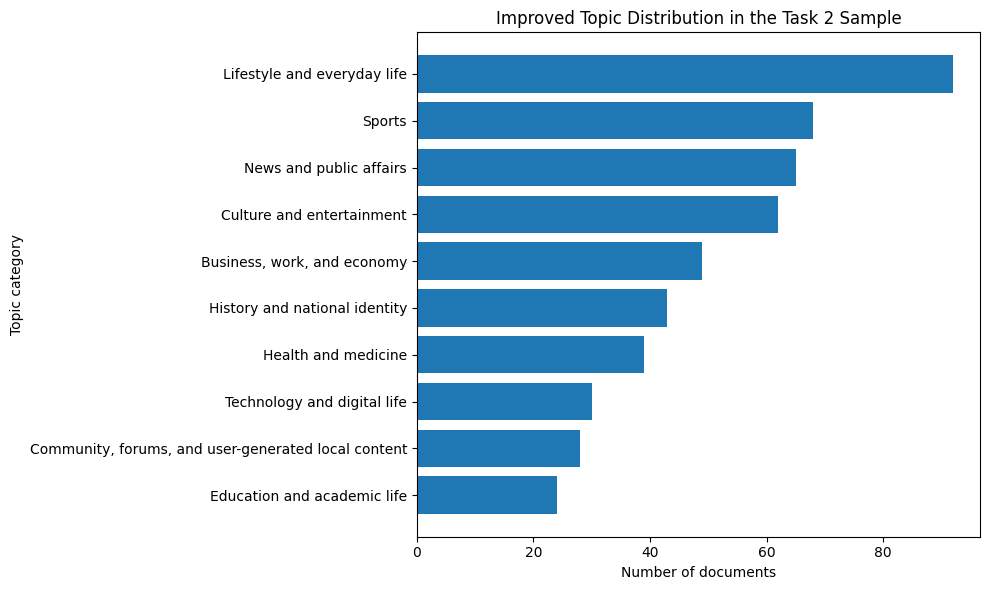

In [38]:
import matplotlib.pyplot as plt

topic_counts = topic_distribution_improved.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(topic_counts.index, topic_counts.values)
plt.xlabel("Number of documents")
plt.ylabel("Topic category")
plt.title("Improved Topic Distribution in the Task 2 Sample")
plt.tight_layout()
plt.show()

## Limitations and next steps

Although the improved clustering result is substantially better than the initial baseline, it still has several limitations.

### Current limitations

1. **Some clusters remain mixed**
   Even after dimensionality reduction and improved clustering, some clusters still combine multiple related but distinct content types.

2. **The analysis is based on a small working sample**
   The current distribution is estimated from 500 documents only, so it should be treated as indicative rather than definitive.

3. **The final topic labels still involve manual interpretation**
   The cluster-to-category mapping is informed by representative examples, but it is not yet a fully automatic supervised topic classifier.

4. **Some target categories remain underrepresented or not clearly separated**
   Categories such as:
   - Government and public services
   - Travel, geography, and local places
   - Environment, climate, and rural Australia

   may still be present in the data, but they are not yet strongly isolated in the current working sample.

### Next steps

1. Increase the sample size and repeat the improved clustering workflow.
2. Refine the cluster-to-category mapping with more representative examples.
3. Compare multiple values of `k` more systematically.
4. Use stronger embedding-based text representations when the environment allows.
5. Use the resulting topic distribution to guide future training-data balancing for an Australian-focused small model.

## Executive summary

This notebook develops a first-pass topic analysis workflow for the sampled AU subset, with the downstream goal of supporting future training of a small model with stronger Australian cultural and local-context knowledge.

The main steps were:

1. define an Australia-relevant topic taxonomy
2. create a small working sample
3. build a TF-IDF baseline representation
4. improve clustering with dimensionality reduction
5. inspect representative examples
6. map clusters to a revised 13-category topic system

The improved result suggests that the current sample contains a meaningful mix of topic types, including:

- lifestyle and everyday life
- sports
- news and public affairs
- culture and entertainment
- business and economy
- history and national identity
- health and medicine
- technology and digital life
- community and forum-style local content

This is a promising result for downstream modeling, because it suggests that the sampled AU subset is not dominated by only formal or institutional content. Instead, it also includes categories that are likely to better capture everyday Australian discourse, cultural reference points, and local lived experience.

At the same time, the current result should still be treated as an interpretable first-pass estimate rather than a final topic classifier, because some topic boundaries remain approximate and the current analysis is based on a relatively small sample.

## Improve classification quality with category prototypes

The current improved clustering result is useful, but it still assigns labels at the cluster level.

This can reduce classification quality when a cluster contains mixed content.

To improve the first-pass categorization, this notebook now introduces a prototype-based document classifier.

The idea is:

1. define a short keyword-based prototype for each topic category
2. represent both documents and category prototypes in the same TF-IDF space
3. assign each document to the category whose prototype is most similar

This allows topic labels to be assigned at the document level rather than only at the cluster level.

In [39]:
category_prototypes = {
    "News and public affairs": "news politics public affairs minister election parliament policy crime court law police public debate media reform government issue society",
    "Government and public services": "government public service department agency minister council administration regulation tax medicare centrelink service policy legislation official",
    "History and national identity": "history anzac remembrance memorial war heritage australian identity national story commemoration historical archive veterans",
    "Culture and entertainment": "film movie television tv music artist arts entertainment books author review actor actress library comic festival museum",
    "Lifestyle and everyday life": "lifestyle family parenting relationship children kids home food wellbeing baby daily life blog advice wellness interior",
    "Travel, geography, and local places": "travel tourism trip hotel beach park city suburb regional town local place destination geography road holiday accommodation",
    "Sports": "sport team player match coach final season club league afl nrl cricket rugby football tennis swimming olympics",
    "Education and academic life": "education school student university teacher classroom literacy learning curriculum naplan academic training degree campus",
    "Business, work, and economy": "business company bank finance market economy executive board employment workplace industry trade housing shares investment",
    "Health and medicine": "health medical hospital cancer disease diabetes treatment doctor mental health patient medicine healthcare wellbeing clinical",
    "Environment, climate, and rural Australia": "environment climate bushfire drought water rural farming wildlife conservation land weather fire ecology regional",
    "Community, forums, and user-generated local content": "forum discussion community local posts thread hobby comments user review neighbourhood petition club blog",
    "Technology and digital life": "technology digital internet online software computer network hacker cybersecurity tablet smartphone data broadband email device"
}

print("Number of prototypes:", len(category_prototypes))
for category in category_prototypes:
    print("-", category)

Number of prototypes: 13
- News and public affairs
- Government and public services
- History and national identity
- Culture and entertainment
- Lifestyle and everyday life
- Travel, geography, and local places
- Sports
- Education and academic life
- Business, work, and economy
- Health and medicine
- Environment, climate, and rural Australia
- Community, forums, and user-generated local content
- Technology and digital life


## Transform the category prototypes into the same TF-IDF space

This cell converts the category prototypes into TF-IDF vectors using the same fitted vectorizer as the document sample.

In [46]:
prototype_names = list(category_prototypes.keys())
prototype_texts = list(category_prototypes.values())

X_prototypes = tfidf_vectorizer.transform(prototype_texts)

print("Prototype matrix shape:", X_prototypes.shape)

Prototype matrix shape: (13, 5000)


## Assign each document to the most similar category prototype

This cell computes cosine similarity between each document and each category prototype.

Each document is then assigned to the prototype with the highest similarity score.

In [47]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

similarity_matrix = cosine_similarity(X_tfidf, X_prototypes)

best_category_indices = np.argmax(similarity_matrix, axis=1)
best_category_labels = [prototype_names[i] for i in best_category_indices]
best_category_scores = similarity_matrix[np.arange(len(best_category_indices)), best_category_indices]

task2_sample_gdf["topic_category_prototype"] = best_category_labels
task2_sample_gdf["topic_category_prototype_score"] = best_category_scores

task2_sample_gdf[["url", "topic_category_prototype", "topic_category_prototype_score"]].head(10)

,url,topic_category_prototype,topic_category_prototype_score
664,http://blogs.news.com.au/moneystuff/index.php/...,"Community, forums, and user-generated local co...",0.064899
5457,http://www.bicycles.net.au/2010/10/interview-j...,"Travel, geography, and local places",0.064031
5459,http://www.bicycles.net.au/forums/viewtopic.ph...,"Community, forums, and user-generated local co...",0.069840
8507,http://www.kluster.com.au/issuefive/bees/,Lifestyle and everyday life,0.029452
9656,http://www.northerndailyleader.com.au/story/97...,Lifestyle and everyday life,0.056703
9818,http://www.onlymelbourne.com.au/melbourne_deta...,"Business, work, and economy",0.073118
11295,http://www.swimmingvictoria.org.au/news/index....,Sports,0.070342
11448,http://www.theage.com.au/national/a-toast-to-l...,Health and medicine,0.183526
11604,http://www.theroar.com.au/2012/07/21/ufc-149-f...,Sports,0.018518
17401,http://victoriainteriors.blogspot.com.au/2011_...,"Travel, geography, and local places",0.033485


## Prototype-based topic distribution

This cell counts the document-level topic assignments produced by the prototype method.

In [48]:
topic_distribution_prototype = (
    task2_sample_gdf["topic_category_prototype"]
    .to_pandas()
    .value_counts()
)

topic_distribution_prototype

topic_category_prototype
Lifestyle and everyday life                            78
Sports                                                 69
News and public affairs                                60
Business, work, and economy                            46
Travel, geography, and local places                    40
Culture and entertainment                              38
History and national identity                          35
Health and medicine                                    25
Environment, climate, and rural Australia              24
Education and academic life                            23
Community, forums, and user-generated local content    22
Technology and digital life                            20
Government and public services                         20
Name: count, dtype: int64

## Inspect low-confidence assignments

This cell shows the document assignments with the lowest prototype scores.

These are likely to be the cases where the current prototypes are weakest or the document topic is mixed.

In [49]:
task2_sample_gdf.to_pandas().sort_values(
    "topic_category_prototype_score",
    ascending=True
)[["url", "topic_category_prototype", "topic_category_prototype_score", "text"]].head(10)

,url,topic_category_prototype,topic_category_prototype_score,text
668553,http://www.google.com.au/patents/US4386556,"Environment, climate, and rural Australia",0.009155,US 4386556 A\nA coffee maker is comprised of a...
752863,http://www.therefinedgeek.com.au/index.php/tag...,Lifestyle and everyday life,0.009299,So last week saw me pick up the components tha...
377047,http://www.coomaexpress.com.au/story/1173670/p...,"Travel, geography, and local places",0.009303,"GO ON, be a Scrooge this Christmas - everybody..."
321477,http://www.parliament.nsw.gov.au/prod/la/precd...,News and public affairs,0.009445,S.O.174 Divisions - procedure for division\n17...
84692,http://www.jmm.org.au/articles/20000.htm,History and national identity,0.011006,John Stott Address at Keswick\nDr. John Stott ...
710843,http://palgn.com.au/nintendo-ds/13595/guitar-r...,"Environment, climate, and rural Australia",0.012158,Presumably there was some point when Gameloft ...
375838,http://www.acga.org.au/goatnotes/G005.php,History and national identity,0.012460,Middle micron fibre or fibre of 19 to 22 micro...
627037,http://trove.nla.gov.au/ndp/del/article/18017952,Sports,0.013471,"* * * FINAL-INSTALMENT OF THE ""HERALD'S"" SECON..."
364045,http://www.afoodstory.com.au/2012/08/ocean-roo...,Lifestyle and everyday life,0.013738,"Dylan and I both love Japanese food, especiall..."
686006,http://www.abc.net.au/rampup/articles/2011/01/...,Lifestyle and everyday life,0.014762,I'm not very good at making New Year's resolut...



## Add a low-confidence category

Some documents have very weak similarity to all category prototypes.

Instead of forcing these documents into a category, we mark very low-confidence cases as:

- `Uncertain / Mixed`

This helps improve category precision.

In [44]:
confidence_threshold = 0.03

task2_sample_gdf["topic_category_prototype_v2"] = task2_sample_gdf["topic_category_prototype"]
task2_sample_gdf.loc[
    task2_sample_gdf["topic_category_prototype_score"] < confidence_threshold,
    "topic_category_prototype_v2"
] = "Uncertain / Mixed"

task2_sample_gdf[["url", "topic_category_prototype", "topic_category_prototype_score", "topic_category_prototype_v2"]].head(10)

,url,topic_category_prototype,topic_category_prototype_score,topic_category_prototype_v2
664,http://blogs.news.com.au/moneystuff/index.php/...,"Community, forums, and user-generated local co...",0.046888,"Community, forums, and user-generated local co..."
5457,http://www.bicycles.net.au/2010/10/interview-j...,"Travel, geography, and local places",0.057306,"Travel, geography, and local places"
5459,http://www.bicycles.net.au/forums/viewtopic.ph...,"Community, forums, and user-generated local co...",0.083433,"Community, forums, and user-generated local co..."
8507,http://www.kluster.com.au/issuefive/bees/,"Business, work, and economy",0.016645,Uncertain / Mixed
9656,http://www.northerndailyleader.com.au/story/97...,Lifestyle and everyday life,0.067373,Lifestyle and everyday life
9818,http://www.onlymelbourne.com.au/melbourne_deta...,"Business, work, and economy",0.074728,"Business, work, and economy"
11295,http://www.swimmingvictoria.org.au/news/index....,Sports,0.076347,Sports
11448,http://www.theage.com.au/national/a-toast-to-l...,Health and medicine,0.140638,Health and medicine
11604,http://www.theroar.com.au/2012/07/21/ufc-149-f...,Sports,0.025261,Uncertain / Mixed
17401,http://victoriainteriors.blogspot.com.au/2011_...,"Travel, geography, and local places",0.052299,"Travel, geography, and local places"


## Strengthen the category prototypes

This cell refines the category prototypes by adding more Australia-relevant and category-specific terms.

The goal is to improve document-level classification quality, especially for categories that were previously underrepresented or easily confused.

In [45]:
category_prototypes = {
    "News and public affairs": (
        "news politics public affairs minister election parliament policy crime court law police "
        "public debate media reform leadership opposition labor liberal greens cabinet senate campaign "
        "prime minister state politics federal politics breaking news"
    ),

    "Government and public services": (
        "government public service department agency minister council administration regulation tax "
        "medicare centrelink service legislation official abs statistics bureau official data census "
        "parliament australia gov department service delivery public administration local council"
    ),

    "History and national identity": (
        "history anzac remembrance memorial war heritage australian identity national story commemoration "
        "historical archive archives veterans remembrance day petrov heritage museum world war "
        "national memory australian story"
    ),

    "Culture and entertainment": (
        "film movie television tv music artist arts entertainment books author review actor actress "
        "library comic festival museum concert album theatre cinema literature celebrity pop culture"
    ),

    "Lifestyle and everyday life": (
        "lifestyle family parenting relationship children kids home food wellbeing baby daily life blog "
        "advice wellness interior household mother father child family life personal blog self help "
        "home improvement"
    ),

    "Travel, geography, and local places": (
        "travel tourism trip hotel beach park city suburb regional town local place destination geography "
        "road holiday accommodation sydney melbourne adelaide perth brisbane canberra nsw victoria "
        "queensland tasmania western australia local guide regional australia"
    ),

    "Sports": (
        "sport team player match coach final season club league afl nrl cricket rugby football tennis "
        "swimming olympics soccer grand final test series coach player performance"
    ),

    "Education and academic life": (
        "education school student university teacher classroom literacy learning curriculum naplan "
        "academic training degree campus school system higher education teacher training"
    ),

    "Business, work, and economy": (
        "business company bank finance market economy executive board employment workplace industry trade "
        "housing shares investment asx reserve bank interest rates rba growth profits management company board"
    ),

    "Health and medicine": (
        "health medical hospital cancer disease diabetes treatment doctor mental health patient medicine "
        "healthcare wellbeing clinical diagnosis recovery illness disease prevention public health"
    ),

    "Environment, climate, and rural Australia": (
        "environment climate bushfire drought water rural farming wildlife conservation land weather fire "
        "ecology regional flood cfa country fire authority heatwave farm australia natural disaster "
        "regional environment"
    ),

    "Community, forums, and user-generated local content": (
        "forum discussion community local posts thread hobby comments user review neighbourhood petition "
        "club blog community discussion local forum online discussion posts page comments thread reply"
    ),

    "Technology and digital life": (
        "technology digital internet online software computer network hacker cybersecurity tablet smartphone "
        "data broadband email device it website server app mobile google telecom digital media online service"
    )
}

print("Number of prototypes:", len(category_prototypes))
for category in category_prototypes:
    print("-", category)

Number of prototypes: 13
- News and public affairs
- Government and public services
- History and national identity
- Culture and entertainment
- Lifestyle and everyday life
- Travel, geography, and local places
- Sports
- Education and academic life
- Business, work, and economy
- Health and medicine
- Environment, climate, and rural Australia
- Community, forums, and user-generated local content
- Technology and digital life


## Add a low-confidence category

Some documents have very weak similarity to all category prototypes.

Instead of forcing these documents into a category, this cell marks very low-confidence cases as:

- `Uncertain / Mixed`

This helps improve category precision.

In [50]:
confidence_threshold = 0.03

task2_sample_gdf["topic_category_prototype_v2"] = task2_sample_gdf["topic_category_prototype"]
task2_sample_gdf.loc[
    task2_sample_gdf["topic_category_prototype_score"] < confidence_threshold,
    "topic_category_prototype_v2"
] = "Uncertain / Mixed"

task2_sample_gdf[[
    "url",
    "topic_category_prototype",
    "topic_category_prototype_score",
    "topic_category_prototype_v2"
]].head(10)

,url,topic_category_prototype,topic_category_prototype_score,topic_category_prototype_v2
664,http://blogs.news.com.au/moneystuff/index.php/...,"Community, forums, and user-generated local co...",0.064899,"Community, forums, and user-generated local co..."
5457,http://www.bicycles.net.au/2010/10/interview-j...,"Travel, geography, and local places",0.064031,"Travel, geography, and local places"
5459,http://www.bicycles.net.au/forums/viewtopic.ph...,"Community, forums, and user-generated local co...",0.069840,"Community, forums, and user-generated local co..."
8507,http://www.kluster.com.au/issuefive/bees/,Uncertain / Mixed,0.029452,Uncertain / Mixed
9656,http://www.northerndailyleader.com.au/story/97...,Lifestyle and everyday life,0.056703,Lifestyle and everyday life
9818,http://www.onlymelbourne.com.au/melbourne_deta...,"Business, work, and economy",0.073118,"Business, work, and economy"
11295,http://www.swimmingvictoria.org.au/news/index....,Sports,0.070342,Sports
11448,http://www.theage.com.au/national/a-toast-to-l...,Health and medicine,0.183526,Health and medicine
11604,http://www.theroar.com.au/2012/07/21/ufc-149-f...,Uncertain / Mixed,0.018518,Uncertain / Mixed
17401,http://victoriainteriors.blogspot.com.au/2011_...,"Travel, geography, and local places",0.033485,"Travel, geography, and local places"


## Prototype-based topic distribution with uncertainty handling

This cell counts the topic assignments after introducing the `Uncertain / Mixed` category.

The goal is to produce a cleaner distribution by not forcing very weak matches into a normal topic label.

In [51]:
topic_distribution_prototype_v2 = (
    task2_sample_gdf["topic_category_prototype_v2"]
    .to_pandas()
    .value_counts()
)

topic_distribution_prototype_v2

topic_category_prototype_v2
Lifestyle and everyday life                            65
Sports                                                 64
Uncertain / Mixed                                      59
News and public affairs                                55
Business, work, and economy                            39
Culture and entertainment                              36
Travel, geography, and local places                    35
History and national identity                          26
Health and medicine                                    23
Education and academic life                            22
Community, forums, and user-generated local content    20
Technology and digital life                            19
Environment, climate, and rural Australia              19
Government and public services                         18
Name: count, dtype: int64

## Prototype-based topic distribution as proportions

This cell converts the updated topic counts into proportions of the Task 2 sample.

This makes the distribution easier to interpret and compare across categories.

In [53]:
topic_distribution_prototype_v2_prop = (
    task2_sample_gdf["topic_category_prototype_v2"]
    .to_pandas()
    .value_counts(normalize=True)
    .round(4)
)

topic_distribution_prototype_v2_prop

topic_category_prototype_v2
Lifestyle and everyday life                            0.130
Sports                                                 0.128
Uncertain / Mixed                                      0.118
News and public affairs                                0.110
Business, work, and economy                            0.078
Culture and entertainment                              0.072
Travel, geography, and local places                    0.070
History and national identity                          0.052
Health and medicine                                    0.046
Education and academic life                            0.044
Community, forums, and user-generated local content    0.040
Technology and digital life                            0.038
Environment, climate, and rural Australia              0.038
Government and public services                         0.036
Name: proportion, dtype: float64

## Inspect uncertain or mixed cases

This cell displays documents that were marked as `Uncertain / Mixed`.

These are useful for understanding where the current prototype system is still weak or where the document topic is genuinely mixed.

In [54]:
task2_sample_gdf.to_pandas()[
    task2_sample_gdf.to_pandas()["topic_category_prototype_v2"] == "Uncertain / Mixed"
][["url", "topic_category_prototype", "topic_category_prototype_score", "text"]].head(15)

,url,topic_category_prototype,topic_category_prototype_score,text
8507,http://www.kluster.com.au/issuefive/bees/,Uncertain / Mixed,0.029452,photos by Carlo Ledesma\nWhen God was creating...
11604,http://www.theroar.com.au/2012/07/21/ufc-149-f...,Uncertain / Mixed,0.018518,UFC 149 Faber vs. Barao: The Roaring Predictio...
18204,http://www.australianmuseum.net.au/BlogPost/Sc...,Uncertain / Mixed,0.024035,Taking a sample is just the beginning and pres...
32269,http://www.crca.org.au/AboutUs/WhatWeBelieve/C...,Uncertain / Mixed,0.029709,"Human Corruption, Conversion to God,\nand the ..."
56781,http://www.bicycles.net.au/forums/viewtopic.ph...,Uncertain / Mixed,0.028566,"open topic, for anything cycling related.\nOve..."
61473,http://www.races.com.au/2011/07/14/jerezana-ha...,Uncertain / Mixed,0.016694,The first of the two major races at this year’...
84692,http://www.jmm.org.au/articles/20000.htm,Uncertain / Mixed,0.011006,John Stott Address at Keswick\nDr. John Stott ...
100943,http://www.burkeandwills.net.au/Journals/Brahe...,Uncertain / Mixed,0.025967,1 April 1861.\nDuring the first twenty-four\nd...
107786,http://abs.gov.au/ausstats/abs@.nsf/Productsby...,Uncertain / Mixed,0.027635,ESTIMATED RESIDENT POPULATION\nThe estimated r...
149897,http://www.bicycles.net.au/forums/viewtopic.ph...,Uncertain / Mixed,0.020482,"open topic, for anything cycling related.\nI d..."



## Define high-confidence prototype assignments

This cell selects documents whose prototype-based category score is relatively high.

These assignments are more likely to be reliable and are useful for checking the quality of the current category system.

In [55]:
high_conf_threshold = 0.06

high_conf_df = task2_sample_gdf.to_pandas()[
    task2_sample_gdf.to_pandas()["topic_category_prototype_score"] >= high_conf_threshold
].copy()

print("High-confidence documents:", len(high_conf_df))
print("Share of sample:", round(len(high_conf_df) / len(task2_sample_gdf), 4))

High-confidence documents: 311
Share of sample: 0.622


## Topic distribution among high-confidence assignments

This cell shows the topic distribution after restricting the sample to higher-confidence prototype assignments.

This helps reveal which categories remain strong when weaker matches are excluded.

In [56]:
high_conf_distribution = high_conf_df["topic_category_prototype"].value_counts()
high_conf_distribution

topic_category_prototype
Sports                                                 55
News and public affairs                                44
Lifestyle and everyday life                            42
Business, work, and economy                            28
Culture and entertainment                              28
History and national identity                          20
Technology and digital life                            17
Education and academic life                            17
Health and medicine                                    16
Travel, geography, and local places                    15
Community, forums, and user-generated local content    10
Environment, climate, and rural Australia              10
Government and public services                          9
Name: count, dtype: int64

## Inspect representative high-confidence examples by category

This cell prints a few high-confidence examples from each category.

The goal is to verify whether the current prototype assignments are semantically coherent.

In [57]:
categories_to_check = [
    "Lifestyle and everyday life",
    "Sports",
    "News and public affairs",
    "Travel, geography, and local places",
    "History and national identity",
    "Government and public services",
    "Environment, climate, and rural Australia",
    "Technology and digital life"
]

for category in categories_to_check:
    print("=" * 100)
    print("CATEGORY:", category)
    print()

    subset = high_conf_df[high_conf_df["topic_category_prototype"] == category].sort_values(
        "topic_category_prototype_score",
        ascending=False
    ).head(3)

    for _, row in subset.iterrows():
        print("-" * 60)
        print("Score:", round(row["topic_category_prototype_score"], 4))
        print("URL:", row["url"])
        print("Text preview:")
        print(row["text"][:700])
        print()

CATEGORY: Lifestyle and everyday life

------------------------------------------------------------
Score: 0.1905
URL: http://goparents.com.au/about-goparents/
Text preview:
GoParents – Who Are We?
GoParents is a community of Parents and carers, who understand who they are, what they want and make deliberate, conscious choices to make a difference in both their lives as well as their children’s. They are the community who understands that parenting is a skill, like any other skills which needs tweaking. We are parents who make an effort to seek out quality information and education to make a difference for their families. Parents who:
- want to be more confident in their parenting skills
- want to feel connected to themselves as well as their families
- connect to like minded parents and carers through the community
- open mind to receive guidance from parenting

------------------------------------------------------------
Score: 0.1785
URL: http://www.couriermail.com.au/news/queenslan

## Current summary of prototype-based topic classification

At this stage, the prototype-based document classifier with uncertainty handling provides the strongest result in this notebook so far.

Compared with the earlier cluster-level mapping approach, the current method has several advantages:

- it assigns topic labels at the **document level**
- it uses an explicit **13-category Australian-relevant taxonomy**
- it avoids forcing the weakest cases into ordinary categories by introducing an **`Uncertain / Mixed`** label

The current results suggest that the classifier is already reasonably strong for several categories, especially:

- **Sports**
- **News and public affairs**
- **History and national identity**
- **Technology and digital life**
- **Lifestyle and everyday life**

Inspection of higher-confidence examples shows that these categories often contain semantically coherent documents, which means the current prototype system is already capturing meaningful topic structure in the sample.

At the same time, the analysis also shows that some categories remain weaker than others.

In particular, the following categories still need refinement:

- **Government and public services**
- **Environment, climate, and rural Australia**

These categories still attract some semantically mixed assignments, which suggests that their current prototypes are not yet specific enough.

Therefore, the next step is not to redesign the whole method, but to selectively strengthen the weakest prototypes and then rerun the prototype-based classification pipeline.

## Refine the weakest category prototypes

The current prototype-based classifier is already reasonably strong for several categories, including sports, history, news, and technology.

However, inspection of higher-confidence examples suggests that two categories still need stronger and more specific prototype definitions:

- **Government and public services**
- **Environment, climate, and rural Australia**

This cell refines those two prototypes to improve separation from nearby categories.

In [58]:
category_prototypes["Government and public services"] = (
    "government public service department agency minister council administration regulation tax "
    "medicare centrelink service legislation official abs statistics bureau official data census "
    "parliament australia gov department service delivery public administration local council "
    "shire council youth council state government federal government local government "
    "government department public consultation official website government services"
)

category_prototypes["Environment, climate, and rural Australia"] = (
    "environment climate bushfire drought water rural farming wildlife conservation land weather fire "
    "ecology regional flood cfa country fire authority heatwave farm australia natural disaster "
    "regional environment pollution environmental protection epa grass fire conservation bush land "
    "weather fire service climate conditions rural issues"
)

for key in ["Government and public services", "Environment, climate, and rural Australia"]:
    print(key)
    print(category_prototypes[key])
    print()

Government and public services
government public service department agency minister council administration regulation tax medicare centrelink service legislation official abs statistics bureau official data census parliament australia gov department service delivery public administration local council shire council youth council state government federal government local government government department public consultation official website government services

Environment, climate, and rural Australia
environment climate bushfire drought water rural farming wildlife conservation land weather fire ecology regional flood cfa country fire authority heatwave farm australia natural disaster regional environment pollution environmental protection epa grass fire conservation bush land weather fire service climate conditions rural issues



In [59]:
prototype_names = list(category_prototypes.keys())
prototype_texts = list(category_prototypes.values())

X_prototypes = tfidf_vectorizer.transform(prototype_texts)

print("Prototype matrix shape:", X_prototypes.shape)

Prototype matrix shape: (13, 5000)


In [62]:
similarity_matrix = cosine_similarity(X_tfidf, X_prototypes)

best_category_indices = np.argmax(similarity_matrix, axis=1)
best_category_labels = [prototype_names[i] for i in best_category_indices]
best_category_scores = similarity_matrix[np.arange(len(best_category_indices)), best_category_indices]

task2_sample_gdf["topic_category_prototype"] = best_category_labels
task2_sample_gdf["topic_category_prototype_score"] = best_category_scores

In [61]:
confidence_threshold = 0.03

task2_sample_gdf["topic_category_prototype_v2"] = task2_sample_gdf["topic_category_prototype"]
task2_sample_gdf.loc[
    task2_sample_gdf["topic_category_prototype_score"] < confidence_threshold,
    "topic_category_prototype_v2"
] = "Uncertain / Mixed"

topic_distribution_prototype_v2 = (
    task2_sample_gdf["topic_category_prototype_v2"]
    .to_pandas()
    .value_counts()
)

topic_distribution_prototype_v2

topic_category_prototype_v2
Lifestyle and everyday life                            65
Sports                                                 63
Uncertain / Mixed                                      56
News and public affairs                                53
Business, work, and economy                            40
Culture and entertainment                              36
Travel, geography, and local places                    35
History and national identity                          26
Government and public services                         25
Education and academic life                            23
Health and medicine                                    22
Community, forums, and user-generated local content    20
Technology and digital life                            19
Environment, climate, and rural Australia              17
Name: count, dtype: int64

## Summary after prototype refinement

After refining the prototype-based classifier and introducing uncertainty handling, the current document-level topic classification is the strongest result produced in this notebook so far.

This version is preferable to the earlier clustering-only approach because it:

- assigns categories at the **document level**
- uses an explicit **13-category Australian-relevant taxonomy**
- avoids forcing the weakest matches into ordinary topic labels by introducing **`Uncertain / Mixed`**

The current results suggest that several categories are now reasonably stable, especially:

- Lifestyle and everyday life
- Sports
- News and public affairs
- Culture and entertainment
- Business, work, and economy
- Travel, geography, and local places

Other categories, such as Government and public services and Environment, climate, and rural Australia, are weaker but have improved after targeted prototype refinement.

Overall, the current `prototype + uncertainty` result is the most suitable version to use as the notebook’s main topic-distribution result, while still acknowledging that some document assignments remain approximate.

## Final topic distribution used for Task 2

This chart visualizes the final topic distribution based on the prototype-based classifier with uncertainty handling.

This is the main result used in the notebook because it combines:

- document-level topic assignment
- an Australia-relevant 13-category taxonomy
- explicit handling of weak or mixed cases

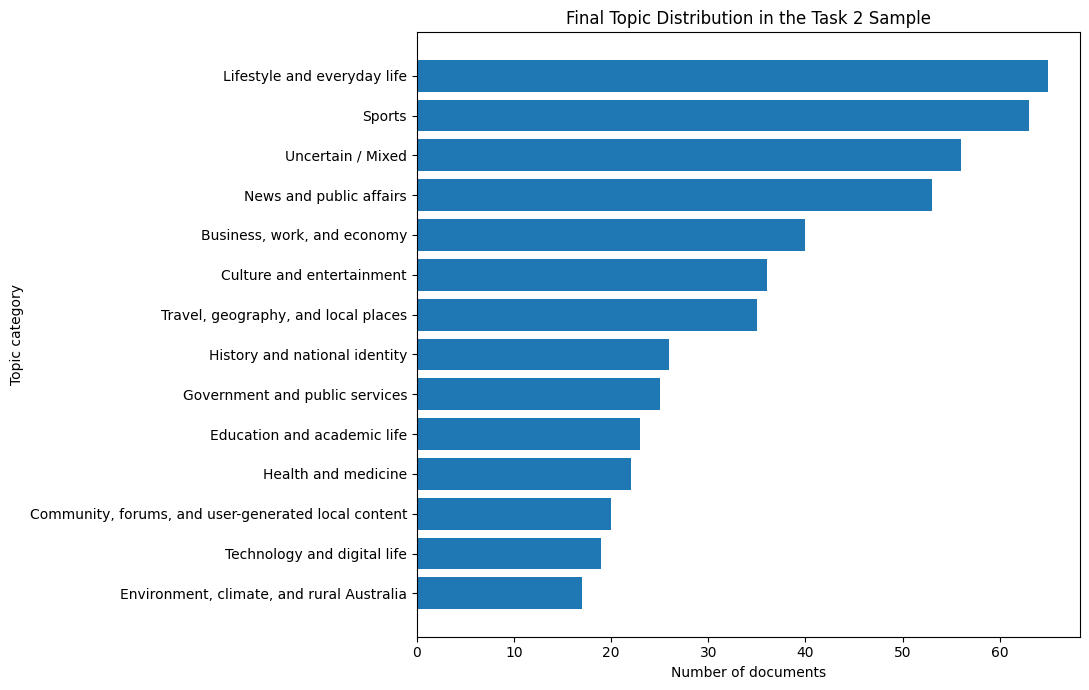

In [64]:
import matplotlib.pyplot as plt

final_topic_counts = topic_distribution_prototype_v2.sort_values(ascending=True)

plt.figure(figsize=(11, 7))
plt.barh(final_topic_counts.index, final_topic_counts.values)
plt.xlabel("Number of documents")
plt.ylabel("Topic category")
plt.title("Final Topic Distribution in the Task 2 Sample")
plt.tight_layout()
plt.show()

## Final conclusion for Task 2

This notebook developed and refined a first-pass topic classification workflow for the sampled AU subset.

The final result used in this notebook is the **prototype-based document classifier with uncertainty handling**, because it performed better than the earlier cluster-level mapping approach.

This final version is preferred because it:

- assigns categories at the **document level**
- uses an explicit **13-category Australian-relevant taxonomy**
- allows weaker cases to remain as **`Uncertain / Mixed`** instead of forcing unreliable assignments

The final result suggests that the sampled AU subset contains a meaningful mix of topic types, including:

- lifestyle and everyday life
- sports
- news and public affairs
- business and economy
- culture and entertainment
- travel, geography, and local places
- history and national identity

This is a promising result for the downstream goal of training a small model with stronger awareness of Australian culture, local context, and everyday discourse.

At the same time, the classifier should still be treated as an interpretable first-pass system rather than a final ground-truth labeler, because:

- some documents remain mixed
- some weaker categories are still harder to separate cleanly
- the analysis is based on a relatively small working sample

Overall, the current workflow provides a useful and defensible estimate of topic distribution, and it is already strong enough to inform future data selection and balancing decisions for Australian-focused model training.